In [1]:
import torchvision
import torchvision.transforms as transforms
import torch
import torch.nn as nn
from torchvision.transforms import v2

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import io
from PIL import Image


device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using mps device


In [3]:
train_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32,scale=True),
    v2.RandomResize(26, 30),
    v2.RandomRotation(50),
    v2.CenterCrop((28,28))
])
val_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32,scale=True),
])

In [4]:
mnist_train = torchvision.datasets.MNIST(root="/Users/loganfoster/projects/ML/AutoEncoders/MNIST", train = True, download=True, transform=train_transforms)
mnist_test = torchvision.datasets.MNIST(root="/Users/loganfoster/projects/ML/AutoEncoders/MNIST", train = False, download=True, transform=val_transforms)

In [5]:
BATCH_SIZE = 256
GRID_SIZE = 8  # Number of images per row/column in the visualization grid

train_loader = torch.utils.data.DataLoader(
    mnist_train,
    batch_size= BATCH_SIZE,
)
test_loader = torch.utils.data.DataLoader(
    mnist_test,
    batch_size= BATCH_SIZE,
)

In [6]:
model = nn.Sequential(
    nn.Conv2d(1, 128, kernel_size=5, stride=1, padding=1),
    nn.Dropout(0.2),
    nn.ReLU(),
    nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
    nn.Dropout(0.2),
    nn.Flatten(),
    nn.Linear(64 * 676, 10),
    #nn.Softmax(dim=1)
).to(device)

In [7]:
model.compile()

In [8]:
mnist_train_images = mnist_train.data.float() / 255.0
X = mnist_train_images.view(-1, 1, 28, 28).to(device)
X.shape
model(X[0].unsqueeze(0))

tensor([[-0.1063, -0.0041, -0.0050, -0.0079,  0.0306,  0.0396,  0.0778, -0.0911,
         -0.0328, -0.0119]], device='mps:0', grad_fn=<LinearBackward0>)

In [10]:
EPOCHS = 10

USE_MIXUP = False

mixup = v2.MixUp(num_classes=10)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(reduction="mean")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        if USE_MIXUP:
            images, labels = mixup(images, labels)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    
    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}")

    model.eval()
    with torch.no_grad():
        correct, total = 0, 0
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")

    torch.save(model.state_dict(), "mnist_mixup_classifier.pth" if USE_MIXUP else "mnist_classifier.pth")

KeyboardInterrupt: 

In [15]:
import torch
import torch.nn as nn

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

model = nn.Sequential(
    nn.Conv2d(1, 128, kernel_size=5, stride=1, padding=1),
    nn.Dropout(0.2),
    nn.ReLU(),
    nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
    nn.Dropout(0.2),
    nn.Flatten(),
    nn.Linear(64 * 676, 10),
    nn.Softmax(dim=1)
).to(device)
model.load_state_dict(torch.load("/Users/loganfoster/projects/ML/mnist_classifier/mnist_classifier.pth"))
model(torch.randn((1,1,28,28), device=device))

Using mps device


tensor([[5.2130e-26, 4.8280e-15, 1.0811e-02, 3.2758e-25, 9.8393e-01, 5.2594e-03,
         7.8823e-23, 7.3623e-26, 2.5158e-10, 2.9722e-12]], device='mps:0',
       grad_fn=<SoftmaxBackward0>)

In [16]:
preds = model(torch.randn((10,1,28,28), device=device))

In [17]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def display_blue_grid(tensor: torch.Tensor):
    """Display an N x 10 tensor as a grid of blue squares with opacity = value."""
    N, cols = tensor.shape
    assert cols == 10, "Tensor must have exactly 10 columns"

    fig, ax = plt.subplots(figsize=(cols, N))
    ax.set_xlim(0, cols)
    ax.set_ylim(0, N)
    ax.set_aspect("equal")
    ax.axis("off")

    for row in range(N):
        for col in range(10):
            opacity = tensor[row, col].item()
            rect = patches.Rectangle(
                (col, N - row - 1),  # bottom-left corner (flip so row 0 is at top)
                1, 1,
                linewidth=0.5,
                edgecolor="gray",
                facecolor=(0, 0, 1, opacity),  # RGBA blue with opacity
            )
            ax.add_patch(rect)

    plt.tight_layout()
    plt.show()

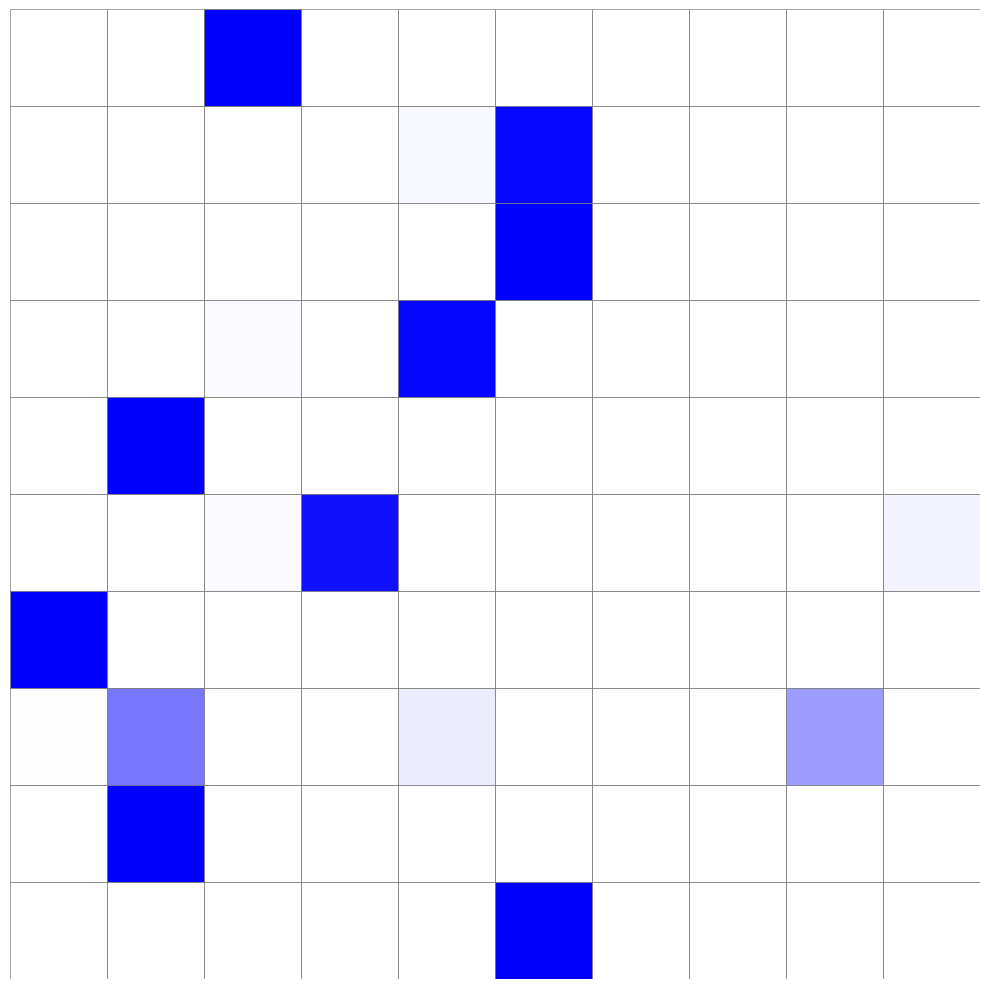

In [6]:
display_blue_grid(preds)

In [23]:
torch.mps.empty_cache()